# Poisson score model on Ligue 1

This notebook trains a `PoissonModel` on the French Ligue 1 season 2024-2025 (via the football-data.co.uk scraper), evaluates it on a held-out matchday, and explores the score distribution of one match with a `GoalMatrix`.

In [1]:
import numpy as np
import pandas as pd

from footix.data_io.footballdata import ScrapFootballData
from footix.metrics import incertity, rps, zscore
from footix.models.basic_poisson import PoissonModel

## Loading the data

`ScrapFootballData` downloads the season once and caches it as a CSV in `./data`. With `force_reload=False` the file is reused if present; the first run requires network access.

In [2]:
dataset = ScrapFootballData(
    competition="FRA Ligue 1", season="2024-2025", path="./data", force_reload=False
).get_fixtures()

dataset["date"] = pd.to_datetime(dataset["date"], dayfirst=True)
dataset = dataset.sort_values("date").reset_index(drop=True)
print(len(dataset), "matches")

306 matches


## Train / test split

Train on the first 279 matches, evaluate on matchday 32 (9 matches), and keep the last two matchdays as a reserve.

In [3]:
train_dataset = dataset.iloc[:-27]
test_dataset = dataset.iloc[-27:-18]
print(len(train_dataset), "training matches")
print(len(test_dataset), "test matches")

279 training matches
9 test matches


## Initialization and fitting

`n_goals` is the number of scorelines considered per team (0 to `n_goals - 1`); probabilities above are truncated and the matrix is renormalized.

In [4]:
model = PoissonModel(n_teams=18, n_goals=20)
model.fit(X_train=train_dataset)

## Evaluation on the held-out matchday

`predict()` returns a `GoalMatrix`; reduce it to 1X2 probabilities with `return_probas()` before scoring. Metrics: `rps` (ranked probability score, lower is better), `incertity` (surprise of the realized outcome), `zscore` (calibration check, seeded for reproducibility, keep the `.z_score` field).

In [5]:
def _outcome_idx(result: str) -> int:
    return {"H": 0, "D": 1, "A": 2}[result]


rps_list, incertity_list, zscore_list = [], [], []
for _, row in test_dataset.iterrows():
    probability = model.predict(
        home_team=row["home_team"], away_team=row["away_team"]
    ).return_probas()
    outcome_idx = _outcome_idx(row["ftr"])
    rps_list.append(rps(probas=probability, outcome_idx=outcome_idx))
    incertity_list.append(incertity(probas=probability, outcome_idx=outcome_idx))
    zscore_list.append(zscore(probas=probability, rps_observed=rps_list[-1], seed=42).z_score)

print(f"Incertity: {np.mean(incertity_list):.3f} +/- {np.std(incertity_list):.3f}")
print(f"RPS:       {np.mean(rps_list):.3f} +/- {np.std(rps_list):.3f}")
print(f"Z-score:   {np.mean(zscore_list):.3f} +/- {np.std(zscore_list):.3f}")

Incertity: 1.030 +/- 0.614
RPS:       0.280 +/- 0.221
Z-score:   0.669 +/- 1.341


## Game focus

Predict the score distribution for St Etienne - Monaco and explore the `GoalMatrix`.

In [6]:
%matplotlib inline

goal_matrix_object = model.predict(home_team="St Etienne", away_team="Monaco")
probability = goal_matrix_object.return_probas()
print("St Etienne - Monaco outcome probabilities")
print(f"Home victory : {100 * probability.proba_home:.2f} %")
print(f"Draw         : {100 * probability.proba_draw:.2f} %")
print(f"Away victory : {100 * probability.proba_away:.2f} %")

St Etienne - Monaco outcome probabilities
Home victory : 14.19 %
Draw         : 19.16 %
Away victory : 66.66 %


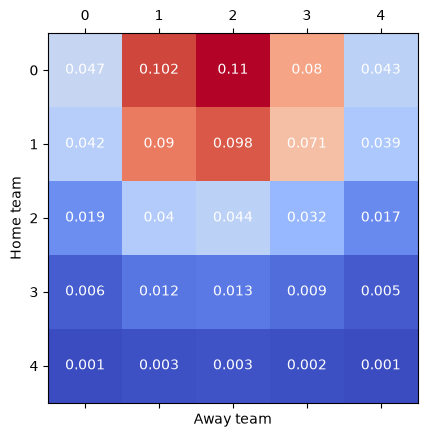

In [7]:
goal_matrix_object.visualize();

In [8]:
print("Most probable score:", goal_matrix_object.get_probable_score())

Most probable score: (0, 2)


## True result

In [9]:
score = test_dataset.loc[
    test_dataset["home_team"] == "St Etienne", ["fthg", "ftag"]
].iloc[0]
print(f"Actual result: {int(score['fthg'])}-{int(score['ftag'])}")

Actual result: 1-3
